In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm
import seaborn as sns
plt.rcParams['text.usetex'] = False
pf.housestyle_rcparams()

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', message='The following kwargs were not used by contour')

In [ ]:
MASTER1 = Table(ascii.read('../catalogue/MASTER_preLSD.csv'))
MASTER2 = Table(ascii.read('../catalogue/MASTER.csv'))
REFCAT = Table(ascii.read('cube_info.csv'))
REFCAT.add_index('name')
REFCAT_headers = ['name','object_fullname','cluster_ra','cluster_dec','source_dir']

refm1 = MASTER1.copy()
refm2 = MASTER2.copy()

for M in [MASTER1,MASTER2]:
    M = M[np.isfinite(M['oiii5007_ew'])]
    M = M[(M['oiii4959_flux']/M['oiii5007_flux'])>0.1]
    M['oiii4959_flux'] = M['oiii5007_flux']/3

MASTER = vstack([MASTER1,MASTER2])


for m in MASTER:
    cname

MUSEWIDE = Table(ascii.read('final_table.csv'))
MUSEWIDE['z'] = MUSEWIDE['Z'] #alias

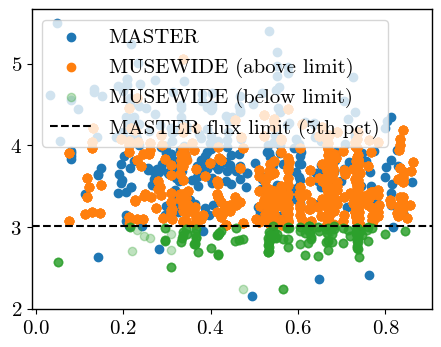

In [3]:
# Derive flux limit from MASTER (e.g. 5th percentile to capture the faint end)
flux_limit = np.nanpercentile(MASTER['oiii5007_flux'], 5)

# Flag MUSEWIDE sources below the MASTER flux limit
MUSEWIDE['above_master_limit'] = MUSEWIDE['WFoiii5007_flux'] >= flux_limit

# Plot
fig, ax = pf.create_plot()

ax.scatter(MASTER['z'], np.log10(MASTER['oiii5007_flux']), label='MASTER')

above = MUSEWIDE[MUSEWIDE['above_master_limit']]
below = MUSEWIDE[~MUSEWIDE['above_master_limit']]

ax.scatter(above['z'], np.log10(above['WFoiii5007_flux']), label='MUSEWIDE (above limit)')
ax.scatter(below['z'], np.log10(below['WFoiii5007_flux']), label='MUSEWIDE (below limit)', alpha=0.3)

ax.axhline(np.log10(flux_limit), color='k', linestyle='--', label=f'MASTER flux limit (5th pct)')
ax.legend()

######OPTIONAL######
MUSEWIDE = MUSEWIDE[MUSEWIDE['above_master_limit']]

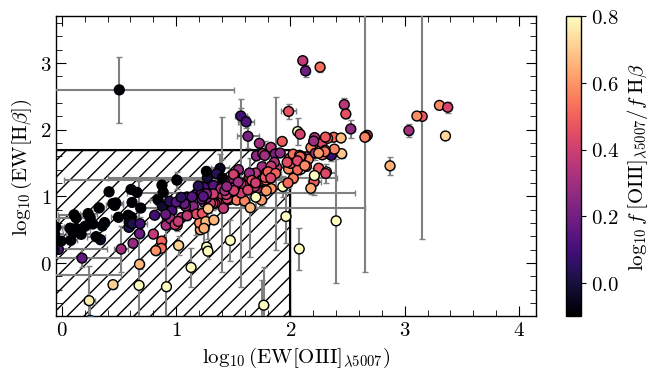

In [4]:
tab = MASTER

fig, ax = pf.create_plot((6,3))
err_x = 0.434*(tab['oiii5007_ew_err']/(tab['oiii5007_ew']))
err_y = 0.434*np.abs(tab['hbeta_ew_err']/(tab['hbeta_ew']))

err_y[err_y>1]=1+np.random.normal(0,0.55, size=len(err_y[err_y>1]))
err_x[err_x>1]=1

oiiihbeta = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])


cbar = ax.scatter(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), c=oiiihbeta+np.random.normal(loc=0,scale=.1),s=50, zorder=10, cmap='magma', vmin=-0.1,vmax=0.8, ec='k')
ax.errorbar(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), 
            yerr = err_y, xerr=err_x,
            mfc='None', zorder=9, ecolor='gray', capsize=2, fmt='o')

plt.colorbar(cbar, label=r'$\log_{10}f\;$[OIII]$_{\lambda5007}/f\;$H$\beta$')

ax.set_xlabel(r'$\log_{10}($EW[OIII]$_{\lambda5007}$)')
ax.set_ylabel(r'$\log_{10}($EW[H$\beta$])')

ax.set_xlim(-0.05, 4.15)
ax.set_ylim(-0.8, 3.7)

ax.vlines(2,-100,np.log10(50),color='k')
ax.hlines(np.log10(50),-100,2,color='k')
ax.fill_between([-100,2],-100,np.log10(50), facecolor='white', edgecolor='black', zorder=-10, hatch='//')

pf.fix_plot([ax])
fig.savefig(f'figs/populations.png', dpi=600, bbox_inches='tight')

In [5]:
def do_langeroodi_me(INPUT_TABLE):
    COPY = INPUT_TABLE.copy()
    COPY['Z_dir_gen'] = np.ones_like(COPY['z'])*1.031492
    COPY['Z_dir_gen_err'] = np.ones_like(COPY['z'])*1.031492
    COPY['direct'] = np.ones_like(COPY['z'])

    COPY_MASK = (
        (COPY['oii3726_flux'] > 0) &
        (COPY['oii3729_flux'] > 0) &
        (COPY['hbeta_flux'] > 0) &
        (COPY['oiii5007_flux'] > 0) &
        (COPY['oiii4959_flux'] > 0)
    )
    COPY_CLEAN = COPY[COPY_MASK].copy()

    for p in tqdm(COPY_CLEAN):
        input_dict = {}
        input_dict['redshift'] =  p['z']
        input_dict['OII']      = [p['oii3726_flux']+p['oii3729_flux'], np.sqrt(np.sum(np.array([p['oii3726_flux_err'], p['oii3729_flux_err']])**2))]
        input_dict['Hbeta']    = [p['hbeta_flux'], p['hbeta_flux_err']]
        input_dict['O4959']    = [p['oiii5007_flux']/3, p['oiii4959_flux_err']]
        input_dict['O5007']    = [p['oiii5007_flux'], p['oiii5007_flux_err']]
        input_dict['Hbeta_EW'] = [p['hbeta_ew'], p['hbeta_ew_err']]

        # Optional lines — only include if flux > 0
        if p['hdelta_flux'] > 0:
            input_dict['Hdelta'] = [p['hdelta_flux'], p['hdelta_flux_err']]
        if p['hgamma_flux'] > 0:
            input_dict['Hgamma'] = [p['hgamma_flux'], p['hgamma_flux_err']]

        try:
            galaxy = genesis_metallicity(input_dict)
            p['Z_dir_gen'] = galaxy.metallicity.n
            p['Z_dir_gen_err'] = galaxy.metallicity.s
        except:
            print('failed')
            p['Z_dir_gen'] = np.nan
            p['Z_dir_gen_err'] = np.nan
        
    return COPY_CLEAN
    
def do_langeroodi_mw(INPUT_TABLE):
    COPY = INPUT_TABLE.copy()
    COPY['Z_dir_gen'] = np.ones_like(COPY['z'])*1.031492
    COPY['Z_dir_gen_err'] = np.ones_like(COPY['z'])*1.031492
    COPY['direct'] = np.ones_like(COPY['z'])

    COPY_MASK = (
        (COPY['WFoii_flux'] > 0) &
        (COPY['WFhbeta_flux'] > 0) &
        (COPY['WFoiii5007_flux'] > 0) &
        (COPY['WFoiii4959_flux'] > 0)
    )
    COPY_CLEAN = COPY[COPY_MASK].copy()

    for p in tqdm(COPY_CLEAN):
        input_dict = {}
        input_dict['redshift'] =  p['z']
        input_dict['OII']      = [p['WFoii_flux'], p['WFoii_flux_err']]
        input_dict['Hbeta']    = [p['WFhbeta_flux'], p['WFhbeta_flux_err']]
        input_dict['O4959']    = [p['WFoiii4959_flux'], p['WFoiii4959_flux_err']]
        input_dict['O5007']    = [p['WFoiii5007_flux'], p['WFoiii5007_flux_err']]
        input_dict['Hbeta_EW'] = [p['WFhbeta_ew'], 1]

        try:
            galaxy = genesis_metallicity(input_dict)
            p['Z_dir_gen'] = galaxy.metallicity.n
            p['Z_dir_gen_err'] = galaxy.metallicity.s
        except:
            print('failed')
            p['Z_dir_gen'] = np.nan
            p['Z_dir_gen_err'] = np.nan
        
    return COPY_CLEAN

def get_sfr(hbeta_fluxes, z):
    lum_d = cosmo.luminosity_distance(z).to(u.cm).value
    lum_hb = (hbeta_fluxes*1e-20)*4*np.pi*lum_d**2
    lum_ha = 2.86*lum_hb
    sfr = 7.9*1e-42*lum_ha
    return np.log10(sfr)

In [6]:
MASTER_CLEAN = do_langeroodi_me(MASTER)
MUSEWIDE_CLEAN = do_langeroodi_mw(MUSEWIDE)

 54%|█████▍    | 105/195 [00:23<00:20,  4.44it/s]

failed


100%|██████████| 727/727 [02:30<00:00,  4.84it/s]


In [7]:
MASTER_CLEAN['logSFR'] = get_sfr(MASTER_CLEAN['hbeta_flux'],MASTER_CLEAN['z'])
MUSEWIDE_CLEAN['logSFR'] = get_sfr(MUSEWIDE_CLEAN['WFhbeta_flux'],MUSEWIDE_CLEAN['Z'])

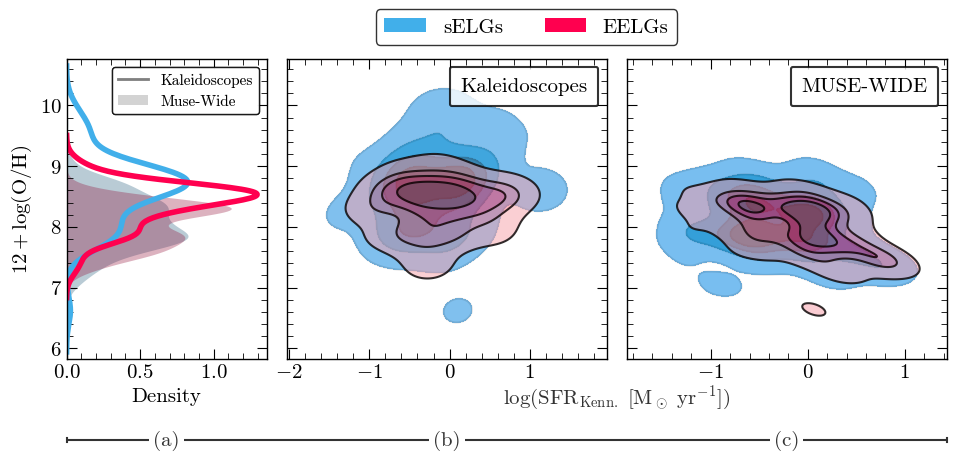

In [8]:
PEAS_MASK = (np.log10(MASTER_CLEAN['oiii5007_ew'])>2)|(np.log10(MASTER_CLEAN['hbeta_ew'])>np.log10(50))
PEAS = MASTER_CLEAN[PEAS_MASK]
NONPEAS = MASTER_CLEAN[~PEAS_MASK]

MW_PEAS_MASK = (np.log10(MUSEWIDE_CLEAN['WFoiii5007_ew'])>2)|(np.log10(MUSEWIDE_CLEAN['WFhbeta_ew'])>np.log10(50))
MW_PEAS = MUSEWIDE_CLEAN[MW_PEAS_MASK]
MW_NONPEAS = MUSEWIDE_CLEAN[~MW_PEAS_MASK]

fig, ax = pf.create_plot((2,3))
ax2 = fig.add_axes((1.1,0,1.6,1),sharey=ax)
ax3 = fig.add_axes((2.8,0,1.6,1),sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)

ax.set_xlabel('Density')
ax.set_ylabel(r'$12+\log(\mathrm{O/H})$')
ax2.set_xlabel(r'$\log($SFR$_{\mathrm{Kenn.}}$ [M$_{\odot}$ yr$^{-1}$])')

#######################################
# AXIS 1 #
#######################################

##### KALEIDOSCOPE #####
sns.kdeplot(y=NONPEAS['Z_dir_gen'], ax=ax, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(y=PEAS['Z_dir_gen'], ax=ax, c='#ff004f', lw=4, label='EELGs')

##### MUSEWIDE #####
sns.kdeplot(y=MW_NONPEAS['Z_dir_gen'], ax=ax, color="#175475ff", lw=0, label='sELGs', fill=True, alpha=0.3, zorder=-10,)
sns.kdeplot(y=MW_PEAS['Z_dir_gen'], ax=ax, color="#8e012dff", lw=0, label='EELGs', fill=True, alpha=0.3,zorder=-10,)

#######################################
# AXIS 2 #
#######################################

LEVELS = 5

##### KALEIDOSCOPE #####
sns.kdeplot(x=NONPEAS['logSFR'], y=NONPEAS['Z_dir_gen'], ax=ax2, color='#41afea', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=NONPEAS['logSFR'], y=NONPEAS['Z_dir_gen'], ax=ax2, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=PEAS['logSFR'], y=PEAS['Z_dir_gen'], ax=ax2, color='#ff004f', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=PEAS['logSFR'], y=PEAS['Z_dir_gen'], ax=ax2, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)

#######################################
# AXIS 3 #
#######################################

##### MUSEWIDE #####
sns.kdeplot(x=MW_NONPEAS['logSFR'], y=MW_NONPEAS['Z_dir_gen'], ax=ax3, color='#175475ff', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=MW_NONPEAS['logSFR'], y=MW_NONPEAS['Z_dir_gen'], ax=ax3, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=MW_PEAS['logSFR'], y=MW_PEAS['Z_dir_gen'], ax=ax3, color='#8e012dff', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=MW_PEAS['logSFR'], y=MW_PEAS['Z_dir_gen'], ax=ax3, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)


##########

from matplotlib.offsetbox import AnchoredText

for ax_, label in [(ax2, r'Kaleidoscopes'), (ax3, 'MUSE-WIDE')]:
    at = AnchoredText(
        label,
        loc='upper right',
        prop=dict(size=15, fontweight='bold'),
        frameon=True,
        pad=0.4,
    )
    at.patch.set_boxstyle("round,pad=0.1")
    at.patch.set_edgecolor('black')
    at.patch.set_linewidth(1.5)
    at.patch.set_facecolor('white')
    at.patch.set_alpha(0.8)
    ax_.add_artist(at)

##########################

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend import Legend

# Survey style indicators
survey_handles = [
    Line2D([0], [0], color='grey', lw=2, label=r'Kaleidoscopes'),
    Patch(facecolor='grey', alpha=0.3, label=r'Muse-Wide'),
]
pop_handles = [
    Patch(facecolor='#41afea', label=r'sELGs'),
    Patch(facecolor='#ff004f', label=r'EELGs'),
]

# Population legend — 2 cols, anchored above the whole figure
fig.legend(handles=pop_handles, loc='upper center', ncol=2,
           bbox_to_anchor=(2.3, 1.2), fontsize=15,
           frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

# Survey legend stays on ax
leg1 = ax.legend(handles=survey_handles, loc='upper right', fontsize=11,
                 frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

ax.add_artist(leg1)

ax2_pos = ax2.get_position()
ax3_pos = ax3.get_position()
mid_x = (ax2_pos.x0 + ax3_pos.x1) / 2
bottom_y = ax2_pos.y0

fig.text(mid_x, bottom_y - 0.08, r'$\log(\mathrm{SFR_{Kenn.}}\ [\mathrm{M_\odot\ yr^{-1}}])$',
         ha='center', va='top', fontsize=15, color='#333333')

# Remove individual xlabels
ax2.set_xlabel('')
ax3.set_xlabel('')



# --- Bottom line with axis-aligned labels ---
ax_positions = [ax, ax2, ax3]
labels = ['(a)', '(b)', '(c)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))


pf.fix_plot([ax,ax2,ax3])

plt.savefig('figs/metals_sfr.pdf', bbox_inches='tight', dpi=500,
            facecolor='white', format='pdf')

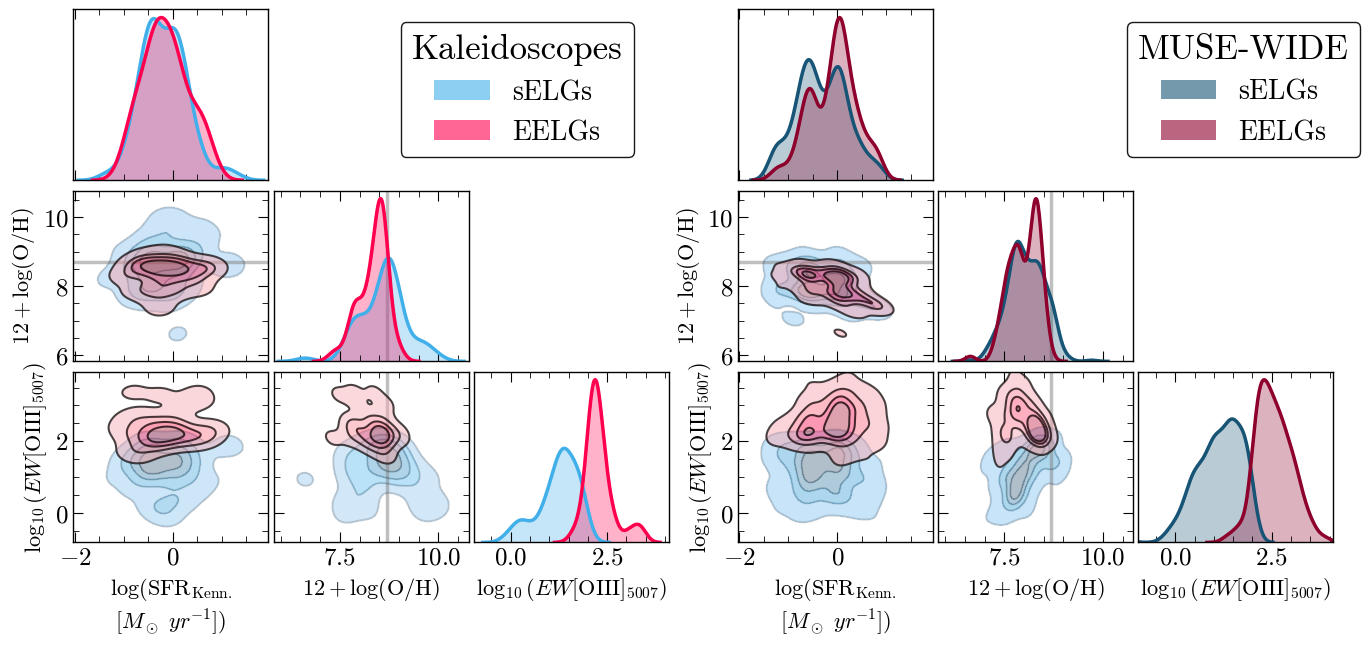

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.offsetbox import AnchoredText

SOLAR_Z = 8.69  # 12 + log(O/H) solar
COLS   = ['logSFR', 'Z_dir_gen', 'log_oiii_ew']
LABELS = [
    r'$\log(\mathrm{SFR_{Kenn.}}$'+'\n'+r'$[M_\odot\ yr^{-1}])$',
    r'$12+\log(\mathrm{O/H})$',
    r'$\log_{10}(EW\mathrm{[OIII]_{5007}})$',
]
N      = len(COLS)
LEVELS = 5
GAP    = 1   # number of empty columns between the two corner plots

STYLES = {
    'KS': {'non': '#41afea', 'pea': '#ff004f'},
    'MW': {'non': '#175475ff', 'pea': '#8e012dff'},
}

# ── Precompute log EW ─────────────────────────────────────────────────────────
# PEAS_MASK    = (np.log10(MASTER_CLEAN['oiii5007_ew']) > 2) | \
#                (np.log10(MASTER_CLEAN['hbeta_ew']) > 1)
# PEAS         = MASTER_CLEAN[PEAS_MASK].copy()
# NONPEAS      = MASTER_CLEAN[~PEAS_MASK].copy()
PEAS['log_oiii_ew']    = np.log10(PEAS['oiii5007_ew'])
NONPEAS['log_oiii_ew'] = np.log10(NONPEAS['oiii5007_ew'])

# MW_PEAS_MASK = (np.log10(MUSEWIDE_CLEAN['WFoiii5007_ew']) > 2) | \
#                (np.log10(MUSEWIDE_CLEAN['WFhbeta_ew']) > 1)
# MW_PEAS      = MUSEWIDE_CLEAN[MW_PEAS_MASK].copy()
# MW_NONPEAS   = MUSEWIDE_CLEAN[~MW_PEAS_MASK].copy()
MW_PEAS['log_oiii_ew']    = np.log10(MW_PEAS['WFoiii5007_ew'])
MW_NONPEAS['log_oiii_ew'] = np.log10(MW_NONPEAS['WFoiii5007_ew'])

# ── Single flat GridSpec: N + GAP + N columns, N rows ─────────────────────────
fig = plt.figure(figsize=(14, 6.5))

total_cols = N + GAP + N
gs = gridspec.GridSpec(
    N, total_cols,width_ratios=[1]*N + [0.3] + [1]*N,  # shrink the gap column
    hspace=0.06, wspace=0.03,
    left=0.07, right=0.97, top=0.92, bottom=0.10,
)

# Build axes arrays by indexing gs directly
def make_axes_from_gs(col_offset):
    axes = [[None]*N for _ in range(N)]
    legend_ax = None
    for row in range(N):
        for col in range(N):
            if col <= row:
                axes[row][col] = fig.add_subplot(gs[row, col_offset + col])
            elif row == 0 and col == N-1:
                # Top-right cell — use for label + legend
                legend_ax = fig.add_subplot(gs[0:2, col_offset + 1: col_offset + N])
                legend_ax.set_axis_off()
    return axes, legend_ax

axes_ks, leg_ax_ks = make_axes_from_gs(0)
axes_mw, leg_ax_mw = make_axes_from_gs(N + GAP)

# ── Sharing: do it after all axes exist ───────────────────────────────────────
def apply_sharing(axes):
    # x: share each column's cells with the bottom cell of that column
    for col in range(N):
        ref = axes[N-1][col]
        for row in range(col, N-1):
            axes[row][col].sharex(ref)
    # y: share each row's off-diagonal cells with the leftmost (col=0)
    for row in range(1, N):
        ref = axes[row][0]
        for col in range(1, row):
            axes[row][col].sharey(ref)

apply_sharing(axes_ks)
apply_sharing(axes_mw)

# ── Fill ──────────────────────────────────────────────────────────────────────
def fill_corner(axes, nonpeas_df, peas_df, style_key, survey_label):
    c_non = STYLES[style_key]['non']
    c_pea = STYLES[style_key]['pea']

    for row in range(N):
        for col in range(N):
            ax = axes[row][col]
            if ax is None:
                continue

            xcol = COLS[col]
            ycol = COLS[row]

            if row == col:
                sns.kdeplot(nonpeas_df[xcol], ax=ax, color=c_non, fill=True, alpha=0.3)
                sns.kdeplot(nonpeas_df[xcol], ax=ax, color=c_non, lw=2.5)
                sns.kdeplot(peas_df[xcol],    ax=ax, color=c_pea,fill=True, alpha=0.3)
                sns.kdeplot(peas_df[xcol],    ax=ax, color=c_pea, lw=2.5)
                ax.set_ylim(bottom=0)
                ax.yaxis.set_visible(False)

            else:
                sns.kdeplot(x=nonpeas_df[xcol], y=nonpeas_df[ycol], ax=ax,
                            color=c_non, fill=True, alpha=0.4, levels=LEVELS, zorder=0)
                sns.kdeplot(x=nonpeas_df[xcol], y=nonpeas_df[ycol], ax=ax,
                            color='k', lw=0.8, fill=False, alpha=0.15, levels=LEVELS, zorder=1)
                sns.kdeplot(x=peas_df[xcol], y=peas_df[ycol], ax=ax,
                            color=c_pea, fill=True, alpha=0.45, levels=LEVELS, zorder=2)
                sns.kdeplot(x=peas_df[xcol], y=peas_df[ycol], ax=ax,
                            color='k', lw=0.8, fill=False, alpha=0.7, levels=LEVELS, zorder=3)
                


                # Add inside fill_corner, after the KDE plotting in each cell:
                if ycol == 'Z_dir_gen' and row != col:
                    ax.axhline(SOLAR_Z, color='gray', lw=2.5, alpha=0.5, zorder=0)
                if xcol == 'Z_dir_gen' and row == col:
                    ax.axvline(SOLAR_Z, color='gray', lw=2.5, alpha=0.5, zorder=0)

            # x labels/ticks: bottom row only
            if row == N - 1:
                ax.set_xlabel(LABELS[col], fontsize=16)
            else:
                ax.set_xlabel('')
                ax.tick_params(axis='x', labelbottom=False,labelsize=18)

            # y labels/ticks: leftmost column, off-diagonal only
            if col == 0 and row != 0:
                ax.set_ylabel(LABELS[row], fontsize=16)
                ax.tick_params(axis='y', labelleft=True,labelsize=18)
            else:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False,labelsize=18)

    # Survey label in top-left cell
    at = AnchoredText(survey_label, loc='upper right',
                      prop=dict(size=12, fontweight='bold'),
                      frameon=True, pad=0.4)
    at.patch.set_boxstyle("round,pad=0.1")
    at.patch.set_edgecolor('black')
    at.patch.set_linewidth(1.5)
    at.patch.set_facecolor('white')
    at.patch.set_alpha(0.8)
    # axes[0][0].add_artist(at)

fill_corner(axes_ks, NONPEAS,    PEAS,    'KS', 'Kaleidoscopes')
fill_corner(axes_mw, MW_NONPEAS, MW_PEAS, 'MW', 'MUSE-WIDE')

for axes in [axes_ks, axes_mw]:
    col = COLS.index('Z_dir_gen')
    for row in range(col, N):
        axes[row][col].axvline(SOLAR_Z, color='gray', lw=2.5, alpha=0.5, zorder=0)

for col in range(N):
    for row in range(col, N):
        xlim = axes_ks[row][col].get_xlim()
        axes_mw[row][col].set_xlim(xlim)
        if row != col:
            ylim = axes_ks[row][col].get_ylim()
            axes_mw[row][col].set_ylim(ylim)

# ── Legend ────────────────────────────────────────────────────────────────────



for leg_ax, label, style_key in [
    (leg_ax_ks, 'Kaleidoscopes', 'KS'),
    (leg_ax_mw, 'MUSE-WIDE',     'MW'),
]:
    pop_handles = [
        Patch(facecolor=STYLES[style_key]['non'], alpha=0.6, label='sELGs'),
        Patch(facecolor=STYLES[style_key]['pea'], alpha=0.6, label='EELGs'),
    ]
    pos = leg_ax.get_position()
    mid_x = (pos.x0 + pos.x1) / 1.83
    mid_y = (pos.y0 + pos.y1) / 1.63

    leg = fig.legend(handles=pop_handles,
                     title=label,
                     loc='center',
                     bbox_to_anchor=(mid_x, mid_y),
                     bbox_transform=fig.transFigure,
                     ncol=1, fontsize=20,
                     title_fontsize=25,
                     frameon=True, edgecolor='black',
                     facecolor='white', framealpha=0.9)
    leg.get_title().set_fontweight('bold')

all_axes = [ax for row in axes_ks + axes_mw for ax in row if ax is not None]
pf.fix_plot(all_axes)

for axes in [axes_ks, axes_mw]:
    for col in range(N):
        axes[N-1][col].tick_params(axis='x', labelsize=18)
    for row in range(1, N):
        axes[row][0].tick_params(axis='y', labelsize=18)


plt.savefig('figs/metals_sfr_corner.pdf',
            bbox_inches='tight', dpi=500,
            facecolor='white', format='pdf')

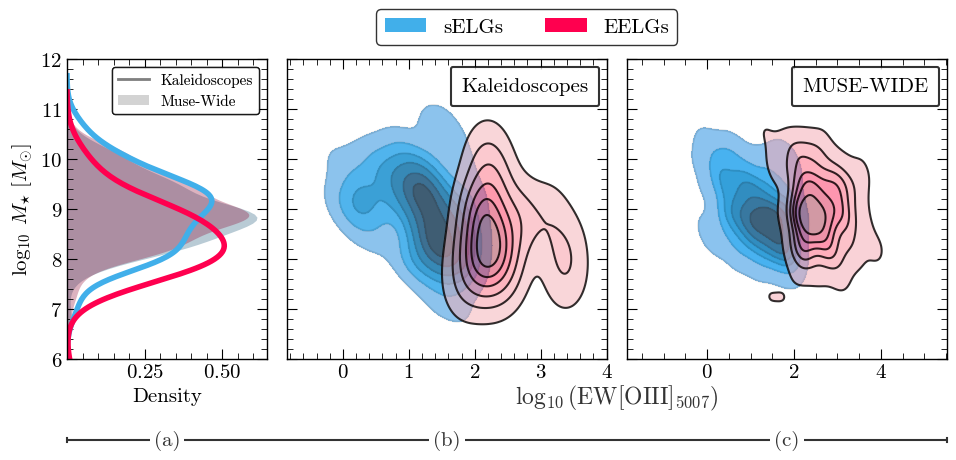

In [10]:
masscat = Table(ascii.read('ELGS_withmasses.csv'))
masscat_short = Table([masscat['object_id'], masscat['logmstellar'],masscat['logmstellar_err']],names=('object_id','logmstellar','logmstellar_error'))

PEAS_MASSES = join(masscat_short, PEAS)
NONPEAS_MASSES = join(masscat_short, NONPEAS)

fig, ax = pf.create_plot((2,3))
ax2 = fig.add_axes((1.1,0,1.6,1),sharey=ax)
ax3 = fig.add_axes((2.8,0,1.6,1),sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)

ax.set_xlabel('Density')
ax.set_ylabel(r'$\log_{10}\;M_{\star}\;[M_{\odot}]$')
ax2.set_xlabel(r'$\log_{10}(EW\mathrm{[OIII]_{5007}})$')

#######################################
# AXIS 1 #
#######################################

##### KALEIDOSCOPE #####
sns.kdeplot(y=NONPEAS_MASSES['logmstellar'], ax=ax, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(y=PEAS_MASSES['logmstellar'], ax=ax, c='#ff004f', lw=4, label='EELGs')

##### MUSEWIDE #####
sns.kdeplot(y=MW_NONPEAS['STELLAR_MASS'], ax=ax, color="#175475ff", lw=0, label='sELGs', fill=True, alpha=0.3, zorder=-10,)
sns.kdeplot(y=MW_PEAS['STELLAR_MASS'], ax=ax, color="#8e012dff", lw=0, label='EELGs', fill=True, alpha=0.3,zorder=-10,)

#######################################
# AXIS 2 #
#######################################

LEVELS = 7

##### KALEIDOSCOPE #####
sns.kdeplot(x=np.log10(NONPEAS_MASSES['oiii5007_ew']), y=NONPEAS_MASSES['logmstellar'], ax=ax2, color='#41afea', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=np.log10(NONPEAS_MASSES['oiii5007_ew']), y=NONPEAS_MASSES['logmstellar'], ax=ax2, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=np.log10(PEAS_MASSES['oiii5007_ew']), y=PEAS_MASSES['logmstellar'], ax=ax2, color='#ff004f', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=np.log10(PEAS_MASSES['oiii5007_ew']), y=PEAS_MASSES['logmstellar'], ax=ax2, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)

#######################################
# AXIS 3 #
#######################################

##### MUSEWIDE #####
sns.kdeplot(x=np.log10(MW_NONPEAS['WFoiii5007_ew']), y=MW_NONPEAS['STELLAR_MASS'], ax=ax3, color='#175475ff', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=np.log10(MW_NONPEAS['WFoiii5007_ew']), y=MW_NONPEAS['STELLAR_MASS'], ax=ax3, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=np.log10(MW_PEAS['WFoiii5007_ew']), y=MW_PEAS['STELLAR_MASS'], ax=ax3, color='#8e012dff', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=np.log10(MW_PEAS['WFoiii5007_ew']), y=MW_PEAS['STELLAR_MASS'], ax=ax3, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)


##########

from matplotlib.offsetbox import AnchoredText

for ax_, label in [(ax2, r'Kaleidoscopes'), (ax3, 'MUSE-WIDE')]:
    at = AnchoredText(
        label,
        loc='upper right',
        prop=dict(size=15, fontweight='bold'),
        frameon=True,
        pad=0.4,
    )
    at.patch.set_boxstyle("round,pad=0.1")
    at.patch.set_edgecolor('black')
    at.patch.set_linewidth(1.5)
    at.patch.set_facecolor('white')
    at.patch.set_alpha(0.8)
    ax_.add_artist(at)

##########################

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend import Legend

# Survey style indicators
survey_handles = [
    Line2D([0], [0], color='grey', lw=2, label=r'Kaleidoscopes'),
    Patch(facecolor='grey', alpha=0.3, label=r'Muse-Wide'),
]
pop_handles = [
    Patch(facecolor='#41afea', label=r'sELGs'),
    Patch(facecolor='#ff004f', label=r'EELGs'),
]

# Population legend — 2 cols, anchored above the whole figure
fig.legend(handles=pop_handles, loc='upper center', ncol=2,
           bbox_to_anchor=(2.3, 1.2), fontsize=15,
           frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

# Survey legend stays on ax
leg1 = ax.legend(handles=survey_handles, loc='upper right', fontsize=11,
                 frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

ax.add_artist(leg1)

ax2_pos = ax2.get_position()
ax3_pos = ax3.get_position()
mid_x = (ax2_pos.x0 + ax3_pos.x1) / 2
bottom_y = ax2_pos.y0

fig.text(mid_x, bottom_y - 0.08, r'$\log_{10}(\mathrm{EW}\mathrm{[OIII]_{5007}})$',
         ha='center', va='top', fontsize=17, color='#333333')

# Remove individual xlabels
ax2.set_xlabel('')
ax3.set_xlabel('')



# --- Bottom line with axis-aligned labels ---
ax_positions = [ax, ax2, ax3]
labels = ['(a)', '(b)', '(c)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

ax.set_ylim(6,12)
ax.set_xticks([0.25,0.5])

pf.fix_plot([ax,ax2,ax3])

plt.savefig('figs/massex.pdf', bbox_inches='tight', dpi=500,
            facecolor='white', format='pdf')

In [11]:
from astroquery.vizier import Vizier

# Query by catalog ID
v = Vizier(columns=["*"])  # "*" = all columns
catalog_list = v.get_catalogs("J/A+A/578/A105")  # replace with your catalog ID
zCOSMOS = catalog_list[0]  # first table in the catalog

In [12]:
def plot_gps(axis, MARKERSIZE = 10):
    brunkerPeas = ascii.read('../cigale_analysis/brunkerPeas.csv')
    # ax.scatter(brunkerPeas['x'], brunkerPeas['y'], color="#d856db", marker='<', label=r'Brunker+2020: $0.2<z<0.4$', edgecolors='k')
    axis.errorbar(brunkerPeas['x'], brunkerPeas['y'], mfc="#d856db", fmt='o', ms=MARKERSIZE,
                label=r'Brunker+2020: $0.2<z<0.4$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(brunkerPeas['y']))),
                ecolor='None', capsize=2)

    yangBlues = ascii.read('../cigale_analysis/yangPs.csv')
    # ax.scatter(yangBlues['x'], yangBlues['y'], color="#77aca2", marker='^', label=r'Yang+2017: $0.1<z<0.36$', edgecolors='k')

    axis.errorbar(yangBlues['x'], yangBlues['y'], mfc="#77aca2", fmt='o', ms=MARKERSIZE,
                label=r'Yang+2017: $0.1<z<0.36$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(yangBlues['y']))),
                ecolor='None', capsize=2)

    yangPeas = ascii.read('../cigale_analysis/yangBlues.csv')
    # ax.scatter(yangPeas['x'], yangPeas['y'], color="#4c33c8", marker='>', label=r'Yang+2017: $z\sim0$', edgecolors='k')

    axis.errorbar(yangPeas['x'], yangPeas['y'], mfc="#4c33c8", fmt='o', ms=MARKERSIZE,
                label=r'Yang+2017: $z\sim0$', mec='k', yerr=np.abs(np.random.normal(0,0.02,size=len(yangPeas['y']))),
                ecolor='None', capsize=2)


In [13]:
for p in [PEAS_MASSES,NONPEAS_MASSES]:
    p['logsSFR'] = p['logSFR']-p['logmstellar']
    p['t_univ'] = cosmo.age(p['z']).value
    p['logsSFRms'] = (0.84-0.026*p['t_univ'])*p['logmstellar']-(6.51-0.11*p['t_univ'])-p['logmstellar']
    p['dMS'] = p['logsSFR']-p['logsSFRms']

for p in [MW_PEAS,MW_NONPEAS]:
    p['logsSFR'] = p['logSFR']-p['STELLAR_MASS']
    p['t_univ'] = cosmo.age(p['z']).value
    p['logsSFRms'] = (0.84-0.026*p['t_univ'])*p['STELLAR_MASS']-(6.51-0.11*p['t_univ'])-p['STELLAR_MASS']
    p['dMS'] = p['logsSFR']-p['logsSFRms']

True

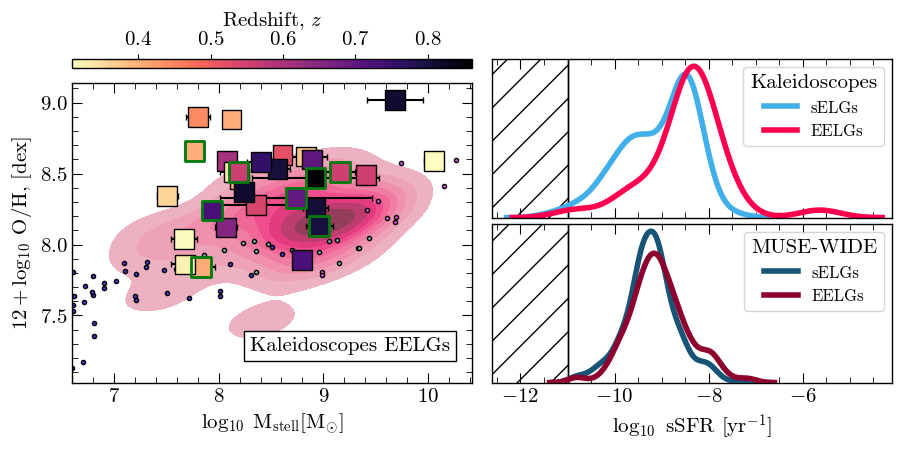

In [14]:

colors = "#ff4681"
fig,ax = pf.create_plot()

#######################################
# AXIS 1 #
#######################################

sns.kdeplot(x=zCOSMOS['logMs'], y=zCOSMOS['Ab(O)'], color="#f383a7", fill=True,zorder=-12, ax=ax, alpha=1)
# sns.kdeplot(x=MW_PEAS['STELLAR_MASS'], y=MW_PEAS['Z_dir_gen'])
plot_gps(ax, 3)

cmap = ax.scatter(PEAS_MASSES['logmstellar'], PEAS_MASSES['Z_dir_gen'], c=PEAS_MASSES['z'],edgecolor='k', marker='s', s=200, zorder=10, cmap='magma_r')
ax.errorbar(PEAS_MASSES['logmstellar'], PEAS_MASSES['Z_dir_gen'],xerr=2*PEAS_MASSES['logmstellar_error'], yerr=PEAS_MASSES['Z_dir_gen_err'], ecolor='k', capsize=2, color='none', zorder=-10)
# cmap = ax.scatter(NONPEAS_MASSES['logmstellar'], NONPEAS_MASSES['Z_dir_gen'], c=NONPEAS_MASSES['z'],edgecolor='k', marker='s', s=100, zorder=10, cmap='magma_r')
# ax.errorbar(NONPEAS_MASSES['logmstellar'], NONPEAS_MASSES['Z_dir_gen'],xerr=NONPEAS_MASSES['logmstellar_error'], yerr=NONPEAS_MASSES['Z_dir_gen_err'], ecolor='k', capsize=2, color='none', zorder=-10)

flag = PEAS_MASSES['nev3426_flux']/PEAS_MASSES['nev3426_flux_err'] > 5
ax.scatter(PEAS_MASSES['logmstellar'][flag], PEAS_MASSES['Z_dir_gen'][flag], marker='s', s=200, zorder=10, facecolor='None', edgecolor="#007c0e", lw=2)

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}]$')

ax.set_xlim(6.6)

cax = fig.add_axes((0,1.05,1,0.03))
plt.colorbar(cmap, cax=cax, label='Redshift, $z$', orientation='horizontal')
cax.tick_params(bottom=False, top=True, labeltop=True, labelbottom=False)
cax.xaxis.set_label_position('top')

#######################################
# AXIS 2 #
#######################################

ax2 = fig.add_axes((1.05,0.55,1,0.53))
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_yticks([])

##### KALEIDOSCOPE #####
sns.kdeplot(x=NONPEAS_MASSES['logsSFR'], ax=ax2, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(x=PEAS_MASSES['logsSFR'], ax=ax2, c='#ff004f', lw=4, label='EELGs')

ax2.legend(title='Kaleidoscopes', fontsize=12)

#######################################
# AXIS 3 #
#######################################

ax3 = fig.add_axes((1.05,0,1,0.53), sharex=ax2)
plt.setp(ax3.get_yticklabels(), visible=False)
ax3.set_yticks([])

##### MUSEWIDE #####
clean = MW_NONPEAS['logsSFR']<-4
sns.kdeplot(x=MW_NONPEAS['logsSFR'][clean], ax=ax3, color="#175475ff", lw=4, label='sELGs', fill=False, alpha=1, zorder=10,)
sns.kdeplot(x=MW_PEAS['logsSFR'], ax=ax3, color="#8e012dff", lw=4, label='EELGs', fill=False, alpha=1,zorder=10,)

ax3.set_xlim(-12.6,-4.1)
ax3.legend(title='MUSE-WIDE', fontsize=12)

for a in [ax2,ax3]:
    lims = a.get_ylim()
    a.set_ylim(*lims)
    a.fill_betweenx([-100,100],-100,-11,hatch='/', facecolor='None', zorder=-15)
    a.fill_betweenx([-100,100],-100,-11, facecolor='None', zorder=-15)

#######################################
# TEXT #
#######################################
ax3.set_xlabel(r'$\log_{10}$ sSFR [yr$^{-1}$]')
ax.text(8.3,7.25,'Kaleidoscopes EELGs',bbox=dict(facecolor='white', edgecolor='k', pad=4))
# ax2.text(-7.1,.5,'Kaleidoscopes',bbox=dict(facecolor='white', edgecolor='k', pad=4))
# ax3.text(-7.05,.7,'MUSE-WIDE',bbox=dict(facecolor='white', edgecolor='k', pad=4))

pf.fix_plot([ax,ax2,ax3])

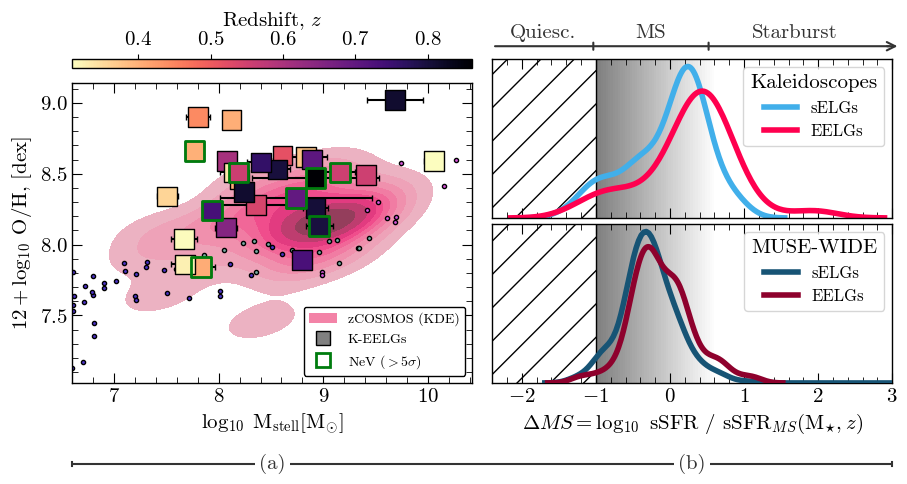

In [15]:

colors = "#ff4681"
fig,ax = pf.create_plot()

#######################################
# AXIS 1 #
#######################################

sns.kdeplot(x=zCOSMOS['logMs'], y=zCOSMOS['Ab(O)'], color="#f383a7", fill=True,zorder=-12, ax=ax, alpha=1)
# sns.kdeplot(x=MW_PEAS['STELLAR_MASS'], y=MW_PEAS['Z_dir_gen'])
plot_gps(ax, 3)

cmap = ax.scatter(PEAS_MASSES['logmstellar'], PEAS_MASSES['Z_dir_gen'], c=PEAS_MASSES['z'],edgecolor='k', marker='s', s=200, zorder=10, cmap='magma_r')
ax.errorbar(PEAS_MASSES['logmstellar'], PEAS_MASSES['Z_dir_gen'],xerr=2*PEAS_MASSES['logmstellar_error'], yerr=PEAS_MASSES['Z_dir_gen_err'], ecolor='k', capsize=2, color='none', zorder=-10)
# cmap = ax.scatter(NONPEAS_MASSES['logmstellar'], NONPEAS_MASSES['Z_dir_gen'], c=NONPEAS_MASSES['z'],edgecolor='k', marker='s', s=100, zorder=10, cmap='magma_r')
# ax.errorbar(NONPEAS_MASSES['logmstellar'], NONPEAS_MASSES['Z_dir_gen'],xerr=NONPEAS_MASSES['logmstellar_error'], yerr=NONPEAS_MASSES['Z_dir_gen_err'], ecolor='k', capsize=2, color='none', zorder=-10)

flag = PEAS_MASSES['nev3426_flux']/PEAS_MASSES['nev3426_flux_err'] > 5
ax.scatter(PEAS_MASSES['logmstellar'][flag], PEAS_MASSES['Z_dir_gen'][flag], marker='s', s=200, zorder=10, facecolor='None', edgecolor="#007c0e", lw=2)

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}]$')

ax.set_xlim(6.6)

cax = fig.add_axes((0,1.05,1,0.03))
plt.colorbar(cmap, cax=cax, label='Redshift, $z$', orientation='horizontal')
cax.tick_params(bottom=False, top=True, labeltop=True, labelbottom=False)
cax.xaxis.set_label_position('top')


legend_elements = [
    Patch(facecolor='#f383a7', edgecolor='none', alpha=1, label='zCOSMOS (KDE)'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='gray',
           markeredgecolor='k', markersize=10, label='K-EELGs'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='none',
           markeredgecolor='#007c0e', markeredgewidth=2, markersize=10,
           label=r'NeV ($>5\sigma$)'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          frameon=True, framealpha=1, edgecolor='k')

#######################################
# AXIS 2 #
#######################################

ax2 = fig.add_axes((1.05,0.55,1,0.53))
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_yticks([])

##### KALEIDOSCOPE #####
sns.kdeplot(x=NONPEAS_MASSES['dMS'], ax=ax2, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(x=PEAS_MASSES['dMS'], ax=ax2, c='#ff004f', lw=4, label='EELGs')

ax2.legend(title='Kaleidoscopes', fontsize=12)

xlim = ax2.get_xlim()          # e.g. (-2.4, 3) after ax3.set_xlim propagates via sharex
bar_y = 1.08                   # in axes-fraction coordinates (above the top spine)
arrow_y = 1.11

# The bracket line (no arrowhead)
ax2.annotate('', xy=(1.0, bar_y), xytext=(0.0, bar_y),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='-', color='#333333', lw=1.5),
             annotation_clip=False)

# The arrow at the right end
ax2.annotate('', xy=(1.02, bar_y), xytext=(0.98, bar_y),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5),
             annotation_clip=False)

# Tick marks at the three regime boundaries
# Map data-space positions to axes fraction for tick placement
x_min, x_max = xlim
ticks_data = [-1.0, 0.6]   # boundaries between Quiesc/MS and MS/Starburst
for xd in ticks_data:
    xf = (xd - x_min) / (x_max - x_min)
    ax2.annotate('', 
                 xy=(xf, bar_y - 0.04),   # extend below the bar
                 xytext=(xf, bar_y + 0.04),  # extend above the bar
                 xycoords='axes fraction', textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='-', color='#333333', lw=1.5),
                 annotation_clip=False)

# Labels for the three regimes
label_positions = [
    ((-2.4 + -1.0) / 2, 'Quiesc.'),   # centre of quiescent zone
    ((-1.0 +  0.6) / 2, 'MS'),         # centre of main-sequence zone
    (( 0.6 +  3.0) / 2, 'Starburst'),  # centre of starburst zone
]

for xd, label in label_positions:
    xf = (xd - x_min) / (x_max - x_min)
    ax2.text(xf, arrow_y, label,
             transform=ax2.transAxes,
             ha='center', va='bottom',
             fontsize=15, color='#333333')

#######################################
# AXIS 3 #
#######################################

ax3 = fig.add_axes((1.05,0,1,0.53), sharex=ax2)
plt.setp(ax3.get_yticklabels(), visible=False)
ax3.set_yticks([])

##### MUSEWIDE #####
# clean = MW_NONPEAS['logsSFR']<-4
sns.kdeplot(x=MW_NONPEAS['dMS'], ax=ax3, color="#175475ff", lw=4, label='sELGs', fill=False, alpha=1, zorder=10,)
sns.kdeplot(x=MW_PEAS['dMS'], ax=ax3, color="#8e012dff", lw=4, label='EELGs', fill=False, alpha=1,zorder=10,)

ax3.set_xlim(-2.4,3)
ax3.legend(title='MUSE-WIDE', fontsize=12)

for a in [ax2,ax3]:
    lims = a.get_ylim()
    a.set_ylim(*lims)
    a.fill_betweenx([-100,100],-100,-1,hatch='/', facecolor='None', zorder=-15)
    # a.fill_betweenx([-100,100],-1,0.6, facecolor='k', zorder=-15, alpha=0.05)
    steps = 50
    x_values = np.linspace(-1, 0.6, steps)
    alphas = np.linspace(0.5, 0, steps)

    for i in range(steps - 1):
        a.fill_betweenx([-100, 100], x_values[i], x_values[i+1], 
                        facecolor='k', alpha=alphas[i], zorder=-15, edgecolor='none')

#######################################
# TEXT #
#######################################
# ax3.set_xlabel(r'$\log_{10}$ sSFR [yr$^{-1}$]')
ax3.set_xlabel(r'$\Delta MS = \log_{10}$ sSFR / sSFR$_{MS}(\mathrm{M}_{\star},z)$')

# ax.text(8.3,7.25,'Kaleidoscopes EELGs',bbox=dict(facecolor='white', edgecolor='k', pad=4))
# ax2.text(-7.1,.5,'Kaleidoscopes',bbox=dict(facecolor='white', edgecolor='k', pad=4))
# ax3.text(-7.05,.7,'MUSE-WIDE',bbox=dict(facecolor='white', edgecolor='k', pad=4))

ax_positions = [ax, ax3]
labels = ['(a)', '(b)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

pf.fix_plot([ax,ax2,ax3])
plt.savefig('figs/massev.png', bbox_inches='tight', dpi=600,
            facecolor='white')

In [16]:
PEAS_MASSES

object_id,logmstellar,logmstellar_error,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,nev3426_flux,nev3426_flux_err,nev3426_ew,nev3426_ew_err,nev3426_centroid,nev3426_fwhm,nev3426_vel_disp,fevii3760_flux,fevii3760_flux_err,fevii3760_ew,fevii3760_ew_err,fevii3760_centroid,fevii3760_fwhm,fevii3760_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp,flux_HST_F435W,flux_HST_F606W,flux_HST_F814W,flux_Spitzer_I1_3.6,flux_Spitzer_I2_4.5,WFC3_F502N,WFC3_F606W,WFC3_F625W,WFC3_F656N,WFC3_F775W,Z_dir_gen,Z_dir_gen_err,direct,logSFR,log_oiii_ew,logsSFR,t_univ,logsSFRms,dMS
str40,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0d47

In [24]:
np.sum(~np.isfinite(MASTER['zcluster']))

np.int64(55)